# **London Energy**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/london_energy.csv")
df

,LCLid,Date,KWH
0,MAC000002,2012-10-12,7.098
1,MAC000002,2012-10-13,11.087
2,MAC000002,2012-10-14,13.223
3,MAC000002,2012-10-15,10.257
4,MAC000002,2012-10-16,9.769
...,...,...,...
3510428,MAC005567,2014-02-24,4.107
3510429,MAC005567,2014-02-25,5.762
3510430,MAC005567,2014-02-26,5.066
3510431,MAC005567,2014-02-27,3.217


In [ ]:
# df.info()
print(df.isna().sum())

LCLid    0
Date     0
KWH      0
dtype: int64


In [ ]:
df_avg_consumption = df.groupby("Date")["KWH"].mean()
df_avg_consumption = pd.DataFrame({"data": df_avg_consumption.index.tolist(), "consumption": df_avg_consumption.values.tolist()})
df_avg_consumption["date"] = pd.to_datetime(df_avg_consumption["data"])
print(f"From: {df_avg_consumption['date'].min()}")
print(f"To: {df_avg_consumption['date'].max()}")

From: 2011-11-23 00:00:00
To: 2014-02-28 00:00:00


<Axes: xlabel='date'>

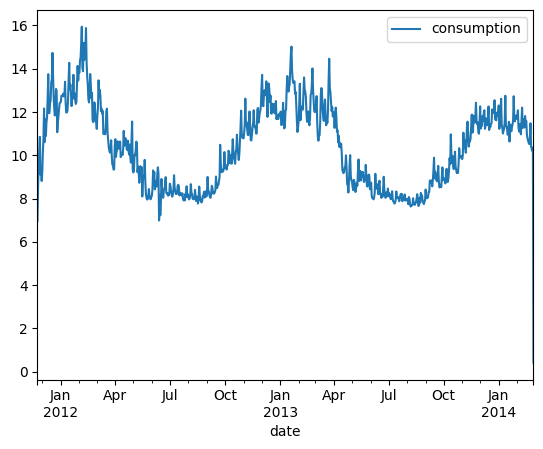

In [ ]:
df_avg_consumption.plot(x="date", y="consumption")

<Axes: xlabel='date'>

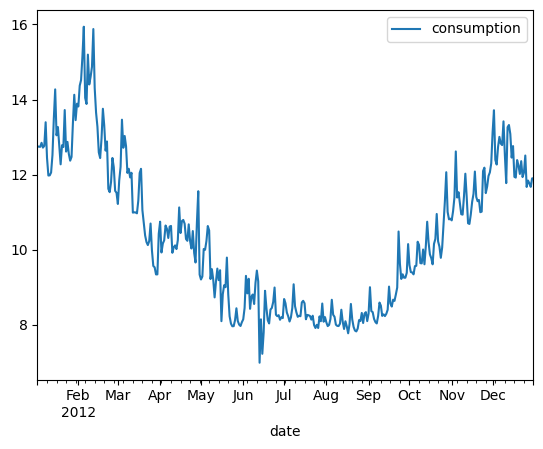

In [ ]:
df_avg_consumption.query("date > '2012-01-01' & date < '2013-01-01'").plot(x="date", y="consumption")

In [ ]:
df_avg_consumption["day_of_week"] = df_avg_consumption["date"].dt.dayofweek
df_avg_consumption["day_of_year"] = df_avg_consumption["date"].dt.dayofyear
df_avg_consumption["month"] = df_avg_consumption["date"].dt.month
df_avg_consumption["quarter"] = df_avg_consumption["date"].dt.quarter
df_avg_consumption["year"] = df_avg_consumption["date"].dt.year

df_avg_consumption.head()

,data,consumption,date,day_of_week,day_of_year,month,quarter,year
0,2011-11-23,6.952692,2011-11-23,2,327,11,4,2011
1,2011-11-24,8.536480,2011-11-24,3,328,11,4,2011
2,2011-11-25,9.499781,2011-11-25,4,329,11,4,2011
3,2011-11-26,10.267707,2011-11-26,5,330,11,4,2011
4,2011-11-27,10.850805,2011-11-27,6,331,11,4,2011


In [ ]:
training_data = df_avg_consumption.loc[df_avg_consumption["date"] < "2013-07-28"]
print(training_data.shape)

testing_data = df_avg_consumption.loc[df_avg_consumption["date"] >= "2013-07-28"]
print(testing_data.shape)

(613, 8)
(216, 8)


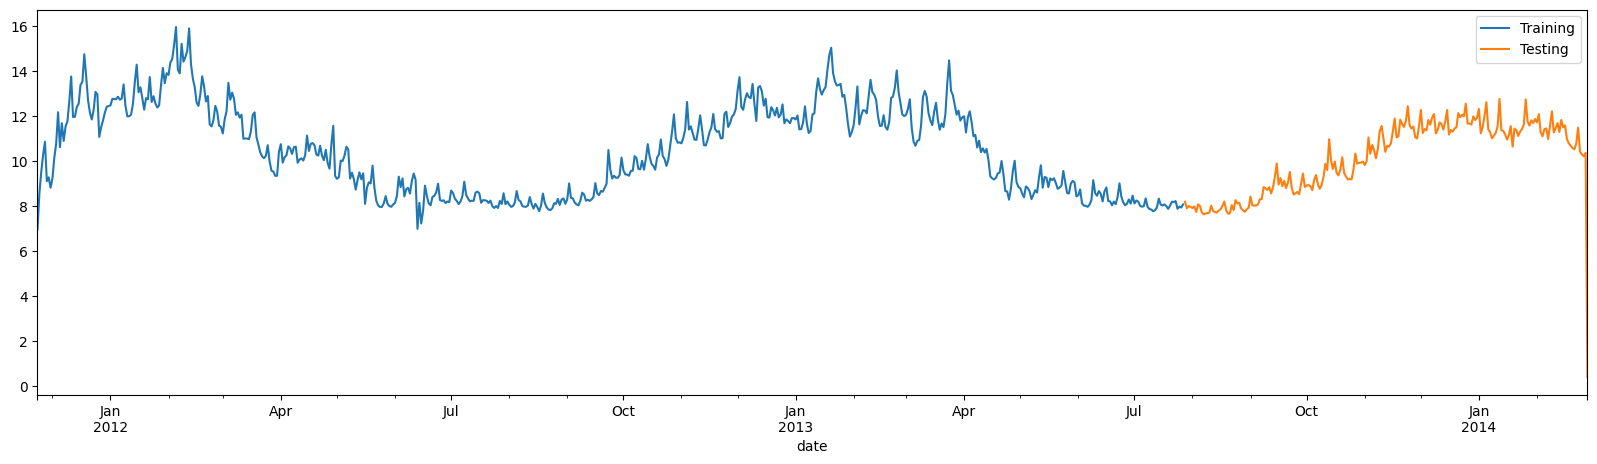

In [ ]:
figure, ax = plt.subplots(figsize=(20, 5))
training_data.plot(ax=ax, label="Training", x="date", y="consumption")
testing_data.plot(ax=ax, label="Testing", x="date", y="consumption")
plt.show()

In [ ]:
# Dropping unnecessary `date` column
training_data = training_data.drop(columns=["date"])
testing_dates = testing_data["date"]
testing_data = testing_data.drop(columns=["date"])

X_train = training_data[["day_of_week", "day_of_year", "month", "quarter", "year"]]
y_train = training_data["consumption"]

X_test = testing_data[["day_of_week", "day_of_year", "month", "quarter", "year"]]
y_test = testing_data["consumption"]

In [ ]:
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# XGBoost
cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = XGBRegressor()
parameters = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [100, 300],
    "colsample_bytree": [0.3]
}

grid_search = GridSearchCV(
    estimator=model,
    cv=cv_split,
    param_grid=parameters
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=100),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, g...
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.3],
                         'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, 5],
                         'n_estimators': [100, 300]})

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,\
  mean_squared_error

def evaluate_model(y_test, prediction):
  print(f"MAE: {mean_absolute_error(y_test, prediction)}")
  print(f"MSE: {mean_squared_error(y_test, prediction)}")
  print(f"MAPE: {mean_absolute_percentage_error(y_test, prediction)}")

def plot_predictions(testing_dates, y_test, prediction):
  df_test = pd.DataFrame({"date": testing_dates, "actual": y_test, "prediction": prediction })
  figure, ax = plt.subplots(figsize=(10, 5))
  df_test.plot(ax=ax, label="Actual", x="date", y="actual")
  df_test.plot(ax=ax, label="Prediction", x="date", y="prediction")
  plt.legend(["Actual", "Prediction"])
  plt.show()

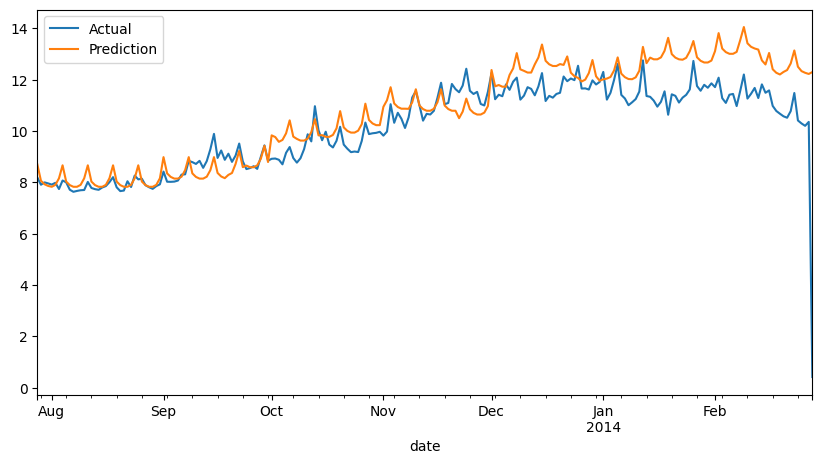

MAE: 0.7750580111197768
MSE: 1.5204474638319045
MAPE: 0.19947948892798412


In [ ]:
# Evaluating GridSearch results
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)

# **London Weather**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

In [ ]:
df_weather = pd.read_csv("/content/london_weather.csv")
print(df_weather.isna().sum())
df_weather.head()

date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [ ]:
# Parsing dates
df_weather["date"] = pd.to_datetime(df_weather["date"], format="%Y%m%d")

# Filling missing values through interpolation
df_weather = df_weather.interpolate(method="ffill")

# Enhancing consu;mption dataset with weather information
df_avg_consumption = df_avg_consumption.merge(df_weather, how="inner", on="date")
df_avg_consumption.head()

/tmp/ipykernel_1577/1221394788.py:5: FutureWarning: DataFrame.interpolate with method=ffill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_weather = df_weather.interpolate(method="ffill")


,data,consumption,date,day_of_week,day_of_year,month,quarter,year,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,2011-11-23,6.952692,2011-11-23,2,327,11,4,2011,7.0,2.0,35.0,13.5,6.8,2.6,0.2,102720.0,0.0
1,2011-11-24,8.536480,2011-11-24,3,328,11,4,2011,3.0,2.0,35.0,12.5,8.6,3.7,0.2,102710.0,0.0
2,2011-11-25,9.499781,2011-11-25,4,329,11,4,2011,3.0,5.0,52.0,14.0,11.0,9.5,0.0,102450.0,0.0
3,2011-11-26,10.267707,2011-11-26,5,330,11,4,2011,4.0,0.7,24.0,13.9,10.2,6.3,0.0,102580.0,0.0
4,2011-11-27,10.850805,2011-11-27,6,331,11,4,2011,3.0,5.9,55.0,13.2,11.8,9.7,0.0,102130.0,0.0


In [ ]:
training_mask = df_avg_consumption["date"] < "2013-07-28"
training_data = df_avg_consumption.loc[training_mask]
print(training_data.shape)

testing_mask = df_avg_consumption["date"] >= "2013-07-28"
testing_data = df_avg_consumption.loc[testing_mask]
print(testing_data.shape)

(613, 17)
(216, 17)


In [ ]:
# Dropping unnecessary `date` column
training_data = training_data.drop(columns=["date"])
testing_dates = testing_data["date"]
testing_data = testing_data.drop(columns=["date"])

X_train = training_data[["day_of_week", "day_of_year", "month", "quarter", "year",\
                         "cloud_cover", "sunshine", "global_radiation", "max_temp",\
                         "mean_temp", "min_temp", "precipitation", "pressure",\
                         "snow_depth"]]
y_train = training_data["consumption"]


X_test = testing_data[["day_of_week", "day_of_year", "month", "quarter", "year",\
                         "cloud_cover", "sunshine", "global_radiation", "max_temp",\
                         "mean_temp", "min_temp", "precipitation", "pressure",\
                         "snow_depth"]]
y_test = testing_data["consumption"]

In [ ]:
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# XGBoost
cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = XGBRegressor()
parameters = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [100, 300],
    "colsample_bytree": [0.3]
}


grid_search = GridSearchCV(estimator=model, cv=cv_split, param_grid=parameters)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=100),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, g...
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.3],
                         'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, 5],
                         'n_estimators': [100, 300]})

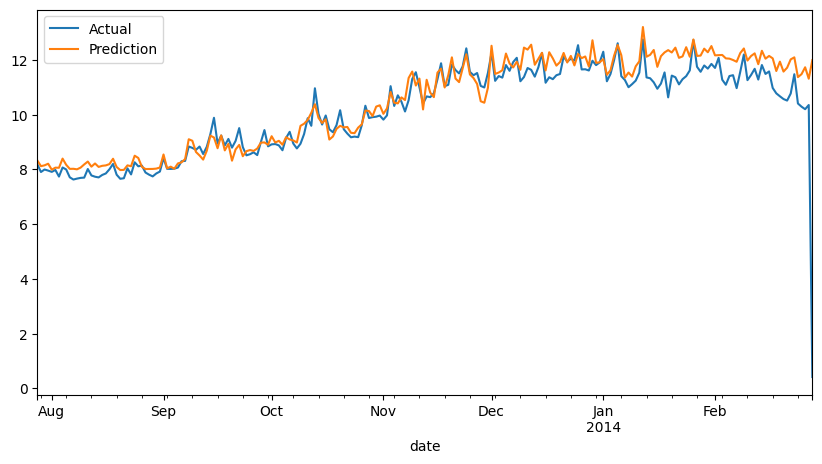

MAE: 0.4383552591482591
MSE: 0.8696847502049204
MAPE: 0.16531553678251096


In [ ]:
# Evaluating GridSearch results
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)

In [ ]:
import sqlite3
from pyvis.network import Network

# 1. Kết nối tới database
conn = sqlite3.connect('codegraph.db')
cursor = conn.cursor()

# 2. Khởi tạo đồ thị Pyvis
net = Network(height="800px", width="100%", directed=True, notebook=False)

# 3. Lấy dữ liệu Nodes (Giới hạn 150-200 node để giao diện không bị giật/lag)
nodes = cursor.execute("SELECT id, name, kind, file_path FROM nodes LIMIT 200").fetchall()
node_ids = set()

for node_id, name, kind, file_path in nodes:
    node_ids.add(node_id)
    label = f"{name} ({kind})"
    title = f"Path: {file_path}\nKind: {kind}"
    # Đặt màu sắc phân biệt theo loại (kind)
    color = "#4CAF50" if kind == "function" else "#2196F3" if kind == "class" else "#FF9800"
    net.add_node(node_id, label=label, title=title, color=color)

# Convert the set of node_ids to a tuple for SQL IN clause
# If node_ids is empty, create a dummy tuple to avoid SQL syntax error with empty IN clause
if not node_ids:
    print("No nodes found to create edges. Exiting.")
    exit()
node_ids_tuple = tuple(node_ids)

# 4. Lấy dữ liệu Edges giữa các node này, đảm bảo chỉ lấy các edge có source và target nằm trong tập node_ids đã thêm vào net
edges = cursor.execute(f"""
    SELECT source, target, kind FROM edges
    WHERE source IN ({','.join(['?' for _ in node_ids_tuple])})
       AND target IN ({','.join(['?' for _ in node_ids_tuple])})
""", node_ids_tuple * 2).fetchall()

for src, tgt, kind in edges:
    net.add_edge(src, tgt, title=kind)

# 5. Xuất file web và mở trực tiếp
net.show("codegraph_view.html", notebook=False)
print("Đã tạo file codegraph_view.html! Mở file này bằng trình duyệt để xem.")

codegraph_view.html
Đã tạo file codegraph_view.html! Mở file này bằng trình duyệt để xem.


In [ ]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.1 MB/s eta 0:00:00
